# Equity Duration – Robustness Measures

Three cross-sectional proxies for equity duration:
- **Shareholder Yield (SY):** (Dividends + Buybacks) / ME
- **Book-to-Market (B/M):** BE / ME
- **Earnings-to-Price (E/P):** NetIncome / ME

Input: `euro500_netpayout.parquet`  
Output: `EQDuration_Robustness.parquet`

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from plot_style import COLORS, set_global_plot_style, style_axes
from project_paths import BASE_DIR, DATA_DIR

set_global_plot_style()


def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")


def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

In [2]:
raw = load_parquet("euro500_netpayout").copy()

# --- Parse dates & identifiers ---
raw["firm_id"] = raw["firm_id"].astype(str).str.strip()

if "date" in raw.columns:
    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    raw["year"] = raw["date"].dt.year
elif "effective_date" in raw.columns:
    raw["effective_date"] = pd.to_datetime(raw["effective_date"], errors="coerce")
    raw["year"] = raw["effective_date"].dt.year
elif "year" not in raw.columns:
    raise KeyError("Input needs date, effective_date, or year column")

raw["year"] = pd.to_numeric(raw["year"], errors="coerce").astype("Int64")

# --- Aggregate to annual: latest observation per firm-year ---
sort_col = "date" if "date" in raw.columns else "effective_date"
raw = raw.sort_values(["firm_id", "year", sort_col], na_position="first")
ann = raw.groupby(["firm_id", "year"], as_index=False).last()
ann["year"] = ann["year"].astype(int)

# --- Ensure CashSTInvst exists ---
if "CashSTInvst" not in ann.columns:
    ann["CashSTInvst"] = np.nan

# --- Lagged variables within firm ---
ann = ann.sort_values(["firm_id", "year"])
for col in ["BE", "Sales"]:
    if col in ann.columns:
        ann[f"{col}_lag1"] = ann.groupby("firm_id")[col].shift(1)

# ME_t = mcap_eur (already in EUR)
ann["ME_t"] = pd.to_numeric(ann["mcap_eur"], errors="coerce")

print(f"Shape (firm-year panel): {ann.shape}")
print(f"Firms: {ann['firm_id'].nunique():,}   Years: {sorted(ann['year'].unique())}")
print(f"Date range: {ann['year'].min()} – {ann['year'].max()}")

# --- Coverage diagnostics ---
cov_cols = ["ME_t", "BE", "NetIncome", "Dividends", "Buybacks", "CashSTInvst"]
cov = {c: ann[c].notna().sum() if c in ann.columns else 0 for c in cov_cols}
print("\nNon-null counts per key column:")
for c, n in cov.items():
    print(f"  {c:<16} {n:>6,}  ({100*n/len(ann):.1f}%)")

Shape (firm-year panel): (15076, 17)
Firms: 1,095   Years: [np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Date range: 1995 – 2025

Non-null counts per key column:
  ME_t             14,108  (93.6%)
  BE               14,970  (99.3%)
  NetIncome        15,033  (99.7%)
  Dividends        12,008  (79.6%)
  Buybacks          9,448  (62.7%)
  CashSTInvst      14,276  (94.7%)


## 2. Shareholder Yield

Two variants:

$$
\text{SY}_{\text{gross}} = \frac{\text{Dividends} + \text{Buybacks}}{\text{ME}_t}
\qquad
\text{SY}_{\text{div\_only}} = \frac{\text{Dividends}}{\text{ME}_t}
$$

Sign convention: LSEG reports Dividends/Buybacks as positive outflows; `abs()` guards against
occasional sign flips in the source data.

In [3]:
def _winsorize_cross_section(series: pd.Series, groups: pd.Series,
                              lo: float = 0.01, hi: float = 0.99) -> pd.Series:
    """Winsorize at lo/hi quantiles cross-sectionally within each group."""
    out = series.copy().astype(float)
    for grp, idx in groups.groupby(groups).groups.items():
        vals = out.loc[idx]
        q_lo = vals.quantile(lo)
        q_hi = vals.quantile(hi)
        out.loc[idx] = vals.clip(lower=q_lo, upper=q_hi)
    return out


# --- Sign-safe payout components ---
div = pd.to_numeric(ann["Dividends"], errors="coerce").abs() if "Dividends" in ann.columns else pd.Series(np.nan, index=ann.index)
bb  = pd.to_numeric(ann["Buybacks"],  errors="coerce").abs() if "Buybacks"  in ann.columns else pd.Series(np.nan, index=ann.index)

# --- Shareholder Yield variants ---

# Variant 1: Gross (Dividends + Buybacks)
# fill_value=0 only where Dividends exist but Buybacks are missing —
# treats missing Buybacks as 'no repurchases' (conservative)
total_payout = div.add(bb, fill_value=0)
ann["SY_gross"] = total_payout / ann["ME_t"]

# Variant 2: Dividends only — higher coverage, more stable for early years
# and firms without buyback reporting
ann["SY_div_only"] = div / ann["ME_t"]

# SY_adj removed: CashSTInvst is not a direct equity issuance measure; Pearson(SY_adj, SY_gross)=0.033

# Mask where ME_t <= 0 or missing
me_invalid = ann["ME_t"].isna() | (ann["ME_t"] <= 0)
ann.loc[me_invalid, ["SY_gross", "SY_div_only"]] = np.nan

# Flag: Buybacks missing (cannot be safely imputed as 0)
ann["flag_sy_buybacks_missing"] = (div.notna() & bb.isna()).astype("Int8")

# --- Winsorize at 1%/99% by year ---
for col in ["SY_gross", "SY_div_only"]:
    ann[f"{col}_w"] = _winsorize_cross_section(ann[col], ann["year"])

ann["flag_sy_negative"] = (ann["SY_gross"] < 0).astype("Int8")

# --- Diagnostics ---
print("SY_gross descriptive stats:")
print(ann["SY_gross"].describe().round(4))
print(f"\nSY_div_only vs SY_gross coverage:")
print(f"  SY_gross    non-null: {ann['SY_gross'].notna().sum():,}  "
      f"({100*ann['SY_gross'].notna().mean():.1f}%)")
print(f"  SY_div_only non-null: {ann['SY_div_only'].notna().sum():,}  "
      f"({100*ann['SY_div_only'].notna().mean():.1f}%)")
print(f"\nBuybacks missing (flag_sy_buybacks_missing): "
      f"{ann['flag_sy_buybacks_missing'].sum():,} obs "
      f"({100*ann['flag_sy_buybacks_missing'].mean():.1f}%)")
print("\nCorrelation SY_gross vs SY_div_only "
      "(quantifies buyback contribution):")
_valid_sy = ann[["SY_gross", "SY_div_only"]].dropna()
print(f"  Pearson  = {_valid_sy['SY_gross'].corr(_valid_sy['SY_div_only']):.3f}")
print(f"\nNegative SY_gross: {ann['flag_sy_negative'].sum():,} ({100*ann['flag_sy_negative'].mean():.1f}%)")

SY_gross descriptive stats:
count    12709.0
mean      0.0614
std       0.3854
min          0.0
25%        0.016
50%       0.0321
75%       0.0597
max      28.8692
Name: SY_gross, dtype: Float64

SY_div_only vs SY_gross coverage:
  SY_gross    non-null: 12,709  (84.3%)
  SY_div_only non-null: 11,723  (77.8%)

Buybacks missing (flag_sy_buybacks_missing): 3,819 obs (25.3%)

Correlation SY_gross vs SY_div_only (quantifies buyback contribution):
  Pearson  = 0.963

Negative SY_gross: 0 (0.0%)


> **Coverage note:** `SY_gross` uses `div.add(bb, fill_value=0)`, which produces a value
> whenever *at least one* of Dividends or Buybacks is non-null. `SY_div_only` is NaN whenever
> Dividends are missing, even if Buybacks are available. This is intentional: `SY_div_only`
> is the cleaner single-source measure, `SY_gross` the more inclusive one.

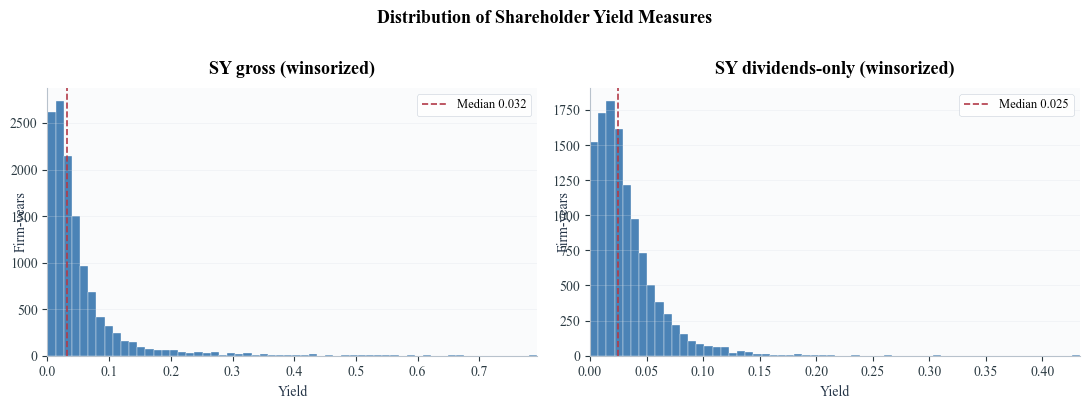

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, label in zip(
    axes,
    ["SY_gross_w", "SY_div_only_w"],
    ["SY gross (winsorized)", "SY dividends-only (winsorized)"],
):
    data = ann[col].dropna()
    ax.hist(data, bins=60, color=COLORS["blue"], edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(data.median(), color=COLORS["accent"], linewidth=1.2, linestyle="--",
               label=f"Median {data.median():.3f}")
    ax.set_title(label)
    ax.set_xlabel("Yield")
    ax.set_ylabel("Firm-years")
    style_axes(ax)
    ax.legend(fontsize=9)

fig.suptitle("Distribution of Shareholder Yield Measures", y=1.01, fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()

## 3. Book-to-Market (B/M)

$$
\text{B/M}_{i,t} = \frac{\text{BE}_{i,t}}{\text{ME}_t}
$$

Requires $\text{BE} > 0$ and $\text{ME}_t > 0$.

In [5]:
be = pd.to_numeric(ann["BE"], errors="coerce") if "BE" in ann.columns else pd.Series(np.nan, index=ann.index)

bm_raw = be / ann["ME_t"]
# Require both BE > 0 and ME_t > 0
bm_raw = bm_raw.where((be > 0) & (ann["ME_t"] > 0))

ann["BM"] = bm_raw
ann["BM_w"] = _winsorize_cross_section(ann["BM"], ann["year"])

print("B/M descriptive stats:")
print(ann["BM"].describe().round(4))
print(f"\nNon-null B/M: {ann['BM'].notna().sum():,}")

# Correlation with SY_gross (expected: positive — both are short-duration proxies;
# value firms (high B/M) tend to pay out more (high SY), consistent with DSS)
valid = ann[["BM", "SY_gross"]].dropna()
corr = valid["BM"].corr(valid["SY_gross"])
print(f"\nCorr(B/M, SY_gross) = {corr:.3f}  (expected: positive — both are short-duration proxies)")

B/M descriptive stats:
count    13959.0
mean      0.8317
std       5.9926
min       0.0002
25%       0.3228
50%        0.551
75%       0.9104
max      479.979
Name: BM, dtype: Float64

Non-null B/M: 13,959

Corr(B/M, SY_gross) = 0.438  (expected: positive — both are short-duration proxies)


## 4. Earnings-to-Price (E/P)

$$
\text{E/P}_{i,t} = \frac{\text{NetIncome}_{i,t}}{\text{ME}_t}
$$

Negative E/P (loss firms) is retained.

In [6]:
ni = pd.to_numeric(ann["NetIncome"], errors="coerce") if "NetIncome" in ann.columns else pd.Series(np.nan, index=ann.index)

ep_raw = ni / ann["ME_t"]
ep_raw = ep_raw.where(ann["ME_t"] > 0)  # only require valid ME_t

ann["EP"] = ep_raw
ann["EP_w"] = _winsorize_cross_section(ann["EP"], ann["year"])

print("E/P descriptive stats:")
print(ann["EP"].describe().round(4))
print(f"\nLoss firms (EP < 0): {(ann['EP'] < 0).sum():,} ({100*(ann['EP'] < 0).mean():.1f}%)")
print(f"Non-null E/P: {ann['EP'].notna().sum():,}")

# Correlations
valid3 = ann[["EP", "BM", "SY_gross"]].dropna()
print(f"\nCorr(E/P, B/M)      = {valid3['EP'].corr(valid3['BM']):.3f}")
print(f"Corr(E/P, SY_gross) = {valid3['EP'].corr(valid3['SY_gross']):.3f}")

E/P descriptive stats:
count    14069.0
mean      0.0735
std       0.8697
min      -8.8494
25%       0.0323
50%       0.0589
75%       0.0934
max      81.5905
Name: EP, dtype: Float64

Loss firms (EP < 0): 1,407 (10.0%)
Non-null E/P: 14,069

Corr(E/P, B/M)      = 0.915
Corr(E/P, SY_gross) = 0.384


## 4b. Expected Payback Period (EPP)

The **Expected Payback Period** is the undiscounted duration analogue: the number of years
until cumulative net payouts equal the current market equity value $\text{ME}_t$.

$$
\text{EPP} = \min\!\left\{h : \sum_{\tau=1}^{h} \text{CF}_{t+\tau} \geq \text{ME}_t \right\}
$$

Cash flows follow the clean-surplus identity:
$$
\text{CF}_h = \text{BE}_{h-1} \cdot (\text{ROE}_h - \text{BEG}_h)
$$
where $\text{ROE}_h$ and $\text{BEG}_h$ follow AR(1) processes with
$\rho_{\text{ROE}} = 0.57$, $\rho_g = 0.24$, $\bar{g} = 0.06$, $\bar{\text{ROE}} = r = 0.12$,
horizon $H = 10$.
Linear interpolation at the crossing point; linear extrapolation if $\text{ME}_t$ not reached within $H$.

EPP non-null : 13,406 (88.9%)
Extrapolated (payback not reached within H=10): 12,222 (91.2%)

EPP descriptive statistics:
count    13406.00
mean        36.44
std        365.43
min          0.02
5%           8.49
10%         10.35
25%         14.03
50%         21.39
75%         34.87
90%         59.26
95%         84.49
max      40184.74
Name: EPP, dtype: float64

EPP_w descriptive statistics:
count    13406.00
mean        30.76
std         32.10
min          1.20
5%           8.49
10%         10.35
25%         14.03
50%         21.39
75%         34.87
90%         59.26
95%         84.49
max        404.12
Name: EPP_w, dtype: float64


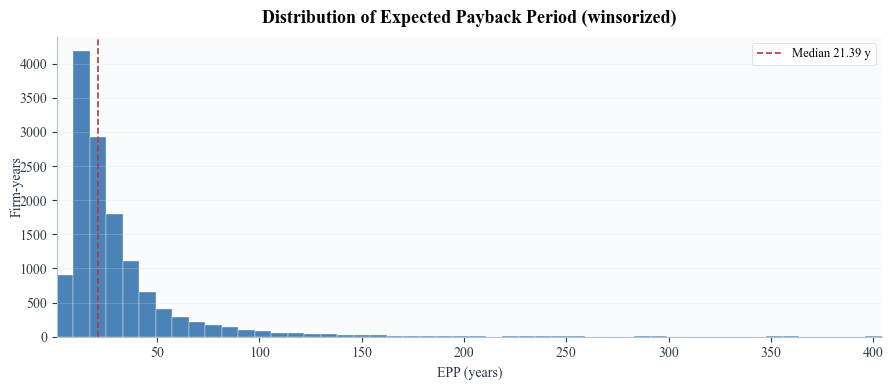


Correlations with EPP_w (expected: negative — short EPP = short duration = high BM/EP/SY):
  Corr(EPP_w, BM_w)       = -0.495
  Corr(EPP_w, EP_w)       = -0.139
  Corr(EPP_w, SY_gross_w) = -0.145


In [7]:
# ============================================================
# SECTION 4b: Expected Payback Period (EPP)
# EPP = undiscounted number of years until cumulative net payouts >= ME_t
# Clean-surplus identity: CF_h = BE_{h-1} * (ROE_h - BEG_h)
# AR(1) mean reversion for ROE and BEG (same parameters as EQDuration_NetPayout)
# ============================================================

# --- Forecasting parameters ---
RHO_ROE = 0.57   # ROE AR(1) persistence
RHO_G   = 0.24   # BEG AR(1) persistence
ROE_BAR = 0.12   # Long-run ROE (= r, cost of equity)
G_BAR   = 0.06   # Long-run book equity growth
H_EPP   = 10     # Maximum explicit horizon (years)


def _compute_epp_row(row):
    """
    AR(1) forecasts of ROE and BEG; EPP = interpolated crossing year.
    Returns (epp, flag_extrapolated).
    """
    me     = float(row["ME_t"])      if pd.notna(row["ME_t"])      else np.nan
    be_lag = float(row["BE_lag1"])   if pd.notna(row["BE_lag1"])   else np.nan
    be     = float(row["BE"])        if pd.notna(row["BE"])        else np.nan
    ni     = float(row["NetIncome"]) if pd.notna(row["NetIncome"]) else np.nan

    # Guard: require positive ME_t and positive BE_{t-1}
    if not (np.isfinite(me) and me > 0 and np.isfinite(be_lag) and be_lag > 0):
        return np.nan, np.nan

    if not np.isfinite(ni):
        return np.nan, np.nan

    roe0 = ni / be_lag
    beg0 = (be - be_lag) / be_lag if (np.isfinite(be) and np.isfinite(be_lag)) else G_BAR

    # AR(1) forecast paths (index 0 = current t; indices 1..H = forecast t+1..t+H)
    roe_path = np.empty(H_EPP + 1)
    beg_path = np.empty(H_EPP + 1)
    roe_path[0] = roe0
    beg_path[0] = beg0
    for h in range(1, H_EPP + 1):
        roe_path[h] = RHO_ROE * roe_path[h - 1] + (1.0 - RHO_ROE) * ROE_BAR
        beg_path[h] = RHO_G   * beg_path[h - 1] + (1.0 - RHO_G)   * G_BAR

    # Book-equity path: BE_h = BE_{h-1} * (1 + BEG_h), starting from BE_lag
    be_p = np.empty(H_EPP + 1)
    be_p[0] = be_lag
    for h in range(1, H_EPP + 1):
        be_p[h] = be_p[h - 1] * (1.0 + beg_path[h])

    # Annual cash flows: CF_h = BE_{h-1} * (ROE_h - BEG_h)
    cfs = np.array([be_p[h - 1] * (roe_path[h] - beg_path[h])
                    for h in range(1, H_EPP + 1)])

    cum_cf = np.cumsum(cfs)

    # Find first year h where cumulative CF >= ME_t
    reached = np.where(cum_cf >= me)[0]  # 0-indexed; year = index + 1

    if len(reached) == 0:
        # Linear extrapolation beyond H: EPP = H + (ME - cumCF_H) / CF_H
        cf_H = cfs[-1]
        if cf_H <= 0 or not np.isfinite(cf_H):
            return np.nan, True
        epp = H_EPP + (me - cum_cf[-1]) / cf_H
        return float(epp), True

    h_idx = reached[0]  # 0-indexed → year h_idx+1 (1-indexed)
    if h_idx == 0:
        # Crossed in first year: interpolate linearly between (0, 0) and (1, cum_cf[0])
        epp = float(me / cum_cf[0]) if cum_cf[0] > 0 else 1.0
        epp = min(epp, 1.0)
    else:
        cum_before = cum_cf[h_idx - 1]
        cum_after  = cum_cf[h_idx]
        denom = cum_after - cum_before
        if denom <= 0:
            return float(h_idx + 1), False
        epp = h_idx + (me - cum_before) / denom

    return float(epp), False


# --- Apply to all firm-years ---
_epp_out = ann.apply(_compute_epp_row, axis=1)
ann["EPP"]                   = [r[0] for r in _epp_out]
ann["flag_epp_extrapolated"] = pd.array([r[1] for r in _epp_out], dtype="boolean")

# --- Winsorize at 1%/99% by year ---
ann["EPP_w"] = _winsorize_cross_section(ann["EPP"], ann["year"])

# --- Descriptive statistics ---
n_epp    = int(ann["EPP"].notna().sum())
n_extrap = int(ann["flag_epp_extrapolated"].fillna(False).sum())
print(f"EPP non-null : {n_epp:,} ({100*n_epp/len(ann):.1f}%)")
print(f"Extrapolated (payback not reached within H={H_EPP}): "
      f"{n_extrap:,} ({100*n_extrap/max(n_epp, 1):.1f}%)")
print("\nEPP descriptive statistics:")
print(ann["EPP"].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).round(2))
print("\nEPP_w descriptive statistics:")
print(ann["EPP_w"].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]).round(2))

# --- Distribution histogram ---
fig, ax = plt.subplots(figsize=(9, 4))
data_epp = ann["EPP_w"].dropna()
ax.hist(data_epp, bins=50, color=COLORS["blue"], edgecolor="white",
        linewidth=0.3, alpha=0.85)
ax.axvline(data_epp.median(), color=COLORS["accent"], linewidth=1.2,
           linestyle="--", label=f"Median {data_epp.median():.2f} y")
ax.set_title("Distribution of Expected Payback Period (winsorized)")
ax.set_xlabel("EPP (years)")
ax.set_ylabel("Firm-years")
style_axes(ax)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Correlations with other duration proxies ---
# Expected: negative — short EPP = short duration = high BM/EP/SY
_corr_epp = ann[["EPP_w", "BM_w", "EP_w", "SY_gross_w"]].dropna()
print("\nCorrelations with EPP_w "
      "(expected: negative — short EPP = short duration = high BM/EP/SY):")
print(f"  Corr(EPP_w, BM_w)       = {_corr_epp['EPP_w'].corr(_corr_epp['BM_w']):.3f}")
print(f"  Corr(EPP_w, EP_w)       = {_corr_epp['EPP_w'].corr(_corr_epp['EP_w']):.3f}")
print(f"  Corr(EPP_w, SY_gross_w) = {_corr_epp['EPP_w'].corr(_corr_epp['SY_gross_w']):.3f}")

## 5. Quality Screens & Sample Diagnostics

In [8]:
N0 = len(ann)
print(f"Starting sample: {N0:,} firm-years")
print()

screens = [
    ("ME_t > 0",           ann["ME_t"].notna() & (ann["ME_t"] > 0)),
    ("BE > 0",             be.notna() & (be > 0)),
    ("Finite NetIncome",   ni.notna() & np.isfinite(ni)),
    ("≥1 measure valid",   ann["SY_gross"].notna() | ann["SY_div_only"].notna() | ann["BM"].notna() | ann["EP"].notna()),
]

mask = pd.Series(True, index=ann.index)
rows = []
for label, condition in screens:
    before = mask.sum()
    mask = mask & condition
    after = mask.sum()
    rows.append({"Screen": label, "Before": before, "After": after, "Dropped": before - after})

screen_df = pd.DataFrame(rows)
print(screen_df.to_string(index=False))
print(f"\nFinal analytic sample: {mask.sum():,} firm-years")

# By-year coverage
print("\nBy-year non-null counts:")
coverage = ann.groupby("year")[["SY_gross", "SY_div_only", "BM", "EP"]].count()
print(coverage.to_string())
print("\nNote: SY_div_only coverage < SY_gross coverage because SY_div_only"
      "\n      requires Dividends to be non-null, while SY_gross is non-null whenever"
      "\n      either Dividends or Buybacks are available (fill_value=0).")

# By-sector if available
sector_col = next((c for c in ["sector", "Sector", "gics_sector", "industry"] if c in ann.columns), None)
if sector_col:
    print(f"\nBy-sector coverage ({sector_col}):")
    sec_cov = ann.groupby(sector_col)[["SY_gross", "SY_div_only", "BM", "EP"]].count()
    print(sec_cov.to_string())
else:
    print("\n[INFO] No sector column found – skipping sector breakdown.")

Starting sample: 15,076 firm-years

          Screen  Before  After  Dropped
        ME_t > 0   15076  14108      968
          BE > 0   14108  13959      149
Finite NetIncome   13959  13924       35
≥1 measure valid   13924  13924        0

Final analytic sample: 13,924 firm-years

By-year non-null counts:
      SY_gross  SY_div_only   BM   EP
year                                 
1995         0            0    4    4
1996       140          127  222  227
1997       199          183  323  327
1998       284          259  453  457
1999       351          311  496  502
2000       393          340  502  506
2001       361          324  471  475
2002       366          333  467  471
2003       393          359  490  487
2004       455          420  487  495
2005       476          434  492  500
2006       483          444  499  503
2007       487          451  502  502
2008       483          453  494  502
2009       486          460  502  502
2010       494          463  506  507
2011   

## 6. Correlation Matrix & Validation

In [9]:
measures = ["SY_gross_w", "SY_div_only_w", "BM_w", "EP_w"]
corr_df = ann[measures].dropna()

pearson  = corr_df.corr(method="pearson")
spearman = corr_df.corr(method="spearman")

print("Pearson correlation:")
print(pearson.round(3).to_string())
print("\nSpearman rank correlation:")
print(spearman.round(3).to_string())

# Flag redundant pairs
print("\nRedundancy check (|Pearson| > 0.8):")
found = False
for i, c1 in enumerate(measures):
    for c2 in measures[i+1:]:
        v = abs(pearson.loc[c1, c2])
        if v > 0.8:
            print(f"  [WARN] {c1} vs {c2}: r = {v:.3f}")
            found = True
if not found:
    print("  None – no pair exceeds 0.8.")

Pearson correlation:
               SY_gross_w  SY_div_only_w   BM_w   EP_w
SY_gross_w          1.000          0.512  0.281  0.066
SY_div_only_w       0.512          1.000  0.322  0.158
BM_w                0.281          0.322  1.000  0.113
EP_w                0.066          0.158  0.113  1.000

Spearman rank correlation:
               SY_gross_w  SY_div_only_w   BM_w   EP_w
SY_gross_w          1.000          0.754  0.305  0.275
SY_div_only_w       0.754          1.000  0.322  0.332
BM_w                0.305          0.322  1.000  0.313
EP_w                0.275          0.332  0.313  1.000

Redundancy check (|Pearson| > 0.8):
  None – no pair exceeds 0.8.


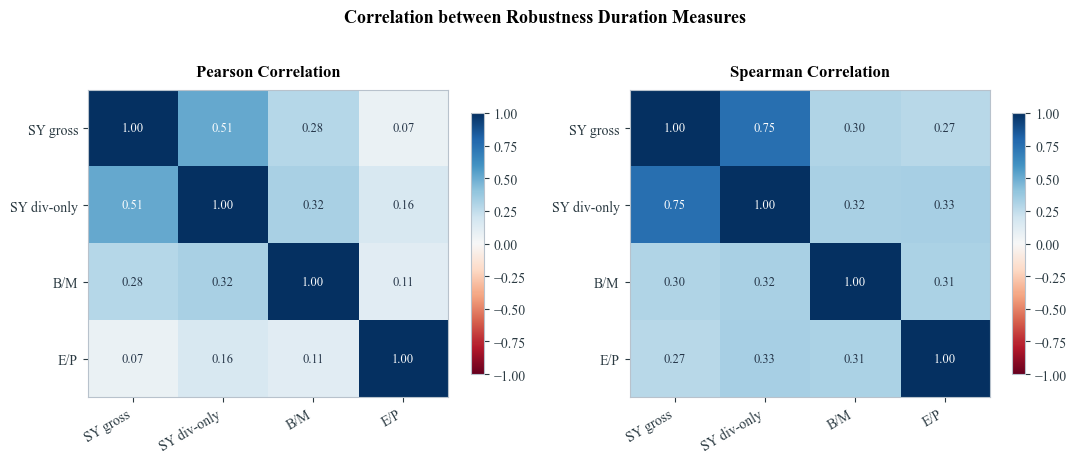

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["SY gross", "SY div-only", "B/M", "E/P"]

for ax, mat, title in zip(axes, [pearson, spearman], ["Pearson", "Spearman"]):
    im = ax.imshow(mat.values, vmin=-1, vmax=1, cmap="RdBu", aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10, rotation=30, ha="right")
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_title(f"{title} Correlation", fontsize=12, fontweight="semibold")
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = mat.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color="white" if abs(val) > 0.5 else "#243447")
    plt.colorbar(im, ax=ax, shrink=0.85)

plt.suptitle("Correlation between Robustness Duration Measures", y=1.02, fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()

## 7. Save Output

In [11]:
output_cols = [
    "firm_id", "year", "ME_t",
    # Raw measures
    "SY_gross", "SY_div_only", "BM", "EP", "EPP",
    # Winsorized
    "SY_gross_w", "SY_div_only_w", "BM_w", "EP_w", "EPP_w",
    # Flags
    "flag_sy_negative", "flag_sy_buybacks_missing", "flag_epp_extrapolated",
]

out = ann[[c for c in output_cols if c in ann.columns]].copy()

out["n_measures_available"] = (
    out[["SY_gross", "BM", "EP", "EPP"]]
    .notna()
    .sum(axis=1)
    .astype("Int8")
)

out = out.sort_values(["firm_id", "year"]).reset_index(drop=True)

save_parquet(out, "EQDuration_Robustness")

print(f"\nFinal shape: {out.shape}")
print(f"Columns: {list(out.columns)}")
print("\nNon-null coverage:")
for col in ["SY_gross", "SY_div_only", "BM", "EP", "EPP",
            "SY_gross_w", "SY_div_only_w", "BM_w", "EP_w", "EPP_w"]:
    if col in out.columns:
        n = out[col].notna().sum()
        print(f"  {col:<16} {n:>6,}  ({100*n/len(out):.1f}%)")
print(f"\nFlag coverage:")
print(f"  flag_sy_buybacks_missing:  "
      f"{out['flag_sy_buybacks_missing'].sum():,} obs")
print(f"  flag_epp_extrapolated:     "
      f"{int(out['flag_epp_extrapolated'].fillna(False).sum()):,} obs")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/EQDuration_Robustness.parquet

Final shape: (15076, 17)
Columns: ['firm_id', 'year', 'ME_t', 'SY_gross', 'SY_div_only', 'BM', 'EP', 'EPP', 'SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w', 'flag_sy_negative', 'flag_sy_buybacks_missing', 'flag_epp_extrapolated', 'n_measures_available']

Non-null coverage:
  SY_gross         12,709  (84.3%)
  SY_div_only      11,723  (77.8%)
  BM               13,959  (92.6%)
  EP               14,069  (93.3%)
  EPP              13,406  (88.9%)
  SY_gross_w       12,709  (84.3%)
  SY_div_only_w    11,723  (77.8%)
  BM_w             13,959  (92.6%)
  EP_w             14,069  (93.3%)
  EPP_w            13,406  (88.9%)

Flag coverage:
  flag_sy_buybacks_missing:  3,819 obs
  flag_epp_extrapolated:     12,222 obs


## 8. Interpretation

### What was computed

Three firm-level proxies for **equity duration** were constructed from annual accounting and
market-cap data for the Euro 500 universe:

| Measure | Formula | Duration interpretation |
|---------|---------|------------------------|
| **SY gross** | (Dividends + Buybacks) / ME | High SY → near-term cash flows → **short** duration |
| **SY div-only** | Dividends / ME | Higher coverage; preferred when buyback data is sparse |
| **B/M** | BE / ME | Value (high B/M) → short duration; growth (low B/M) → long duration |
| **E/P** | NetIncome / ME | Earnings yield; high E/P → current profits dominate → short duration |

All measures are winsorized at 1%/99% cross-sectionally within each year.

### Expected economic signs

- **SY and B/M**: positively correlated — value firms tend to return more cash; both proxy
  short duration (consistent with DSS and Lettau & Wachter).
- **SY and E/P**: positively correlated — profitable firms pay out more.
- **B/M and E/P**: positively correlated in levels (value firms tend to be currently profitable).
- All should be **negatively** correlated with implied/long-horizon duration measures.

### Cross-sectional variation

B/M typically shows the widest cross-sectional dispersion because it reflects cumulative
retained earnings vs. market expectations of future growth. E/P is compressed by loss firms.
SY variants are mechanically bounded near zero for most firms but show meaningful
right-tail variation driven by large repurchasers. `SY_div_only` offers the widest
coverage and is recommended as the primary SY measure.

### Merge readiness

The output table `EQDuration_Robustness.parquet` contains one row per `(firm_id, year)` and
merges directly into the ECB shock regression panel via:

```python
panel.merge(robustness, on=["firm_id", "year"], how="left")
```

Use winsorized variants (`*_w`) in regressions. `SY_div_only_w` is recommended as the
primary SY measure when buyback coverage is a concern.